# PopBeauty
### Exploratory SQL Analysis


---


##1. Setup: Install Dependencies & Connect to the Database

In [ ]:
# Run this cell first, it installs everything needed
!pip install pandas matplotlib seaborn --quiet

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded successfully.")


Libraries loaded successfully.


##2. Upload the Database

Run the cell below, then click **Choose Files** and upload `popbeautydatabase.db`.


In [ ]:
from google.colab import files
uploaded = files.upload()

# Connect
db_filename = list(uploaded.keys())[0]
conn = sqlite3.connect(db_filename)
print(f"Connected to: {db_filename}")

# Quick check — list tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
print("\nTables in database:")
print(tables.to_string(index=False))


Saving popbeautydatabase.db to popbeautydatabase.db
Connected to: popbeautydatabase.db

Tables in database:
               name
             brands
         categories
           products
              sales
          shipments
    store_inventory
             stores
warehouse_inventory
         warehouses


---
## Section A

Before looking at any specific problem, let's understand what we're working with.


### A.1. How many stores do we have, and what types?

In [ ]:
stores = pd.read_sql("""
    SELECT store_id, store_name, city, region, store_size_category
    FROM stores
    ORDER BY store_size_category, store_name
""", conn)
print(stores.to_string(index=False))


store_id           store_name       city        region store_size_category
   ST007       PopBeauty Bath       Bath    South West            Boutique
   ST009 PopBeauty Canterbury Canterbury    South East            Boutique
   ST010     PopBeauty Exeter     Exeter    South West            Boutique
   ST001     PopBeauty London     London    South East            Flagship
   ST002 PopBeauty Birmingham Birmingham West Midlands               Large
   ST012  PopBeauty Edinburgh  Edinburgh      Scotland               Large
   ST013    PopBeauty Glasgow    Glasgow      Scotland               Large
   ST005      PopBeauty Leeds      Leeds     Yorkshire               Large
   ST003 PopBeauty Manchester Manchester    North West               Large
   ST011    PopBeauty Cardiff    Cardiff         Wales              Medium
   ST008   PopBeauty Coventry   Coventry West Midlands              Medium
   ST004  PopBeauty Liverpool  Liverpool    North West              Medium
   ST006       PopBeauty 


> **A.1. Findings: Overview of the Store Network**

> PopBeauty operates 13 stores across 7 regions, spanning four size tiers: 1 Flagship (London), 5 Large stores in major Northern and Scottish cities, 4 Medium stores, and 3 Boutiques in smaller leisure destinations (Bath, Canterbury, Exeter). It is important to keep in mind this tiered structure because it provides context for everything that follows. These stores are not meant to be treated uniformly in terms of inventory allocation because doing so would work against the grain of the network's own geography. For example, a flagship in central London and a boutique in Bath serve fundamentally different customers at fundamentally different volumes.


### A.2. What product categories do we carry?

In [ ]:
pd.read_sql("""
    SELECT c.category_name,
           COUNT(DISTINCT p.product_id) as num_products,
           ROUND(AVG(p.unit_price), 2) as avg_price,
           ROUND(MIN(p.unit_price), 2) as min_price,
           ROUND(MAX(p.unit_price), 2) as max_price
    FROM products p
    JOIN categories c ON p.category_id = c.category_id
    GROUP BY c.category_name
    ORDER BY avg_price DESC
""", conn)


,category_name,num_products,avg_price,min_price,max_price
0,Fragrance,16,154.19,20.96,233.55
1,Beauty Tools,12,105.90,10.60,328.26
2,Makeup,100,59.10,24.22,140.36
3,Skincare,28,52.96,12.14,187.07
4,Beauty Accessories,8,38.94,20.76,72.40
5,Haircare,16,33.03,18.61,56.45


### A.3. How much total stock does each store currently hold?

          store_name store_size_category        region  distinct_skus  total_units_on_hand  avg_units_per_sku
      PopBeauty York              Medium     Yorkshire             84                 5360              63.80
PopBeauty Manchester               Large    North West             92                 5043              54.80
PopBeauty Canterbury            Boutique    South East             78                 4994              64.00
      PopBeauty Bath            Boutique    South West             78                 4946              63.40
PopBeauty Birmingham               Large West Midlands             82                 4870              59.40
   PopBeauty Glasgow               Large      Scotland             80                 4832              60.40
  PopBeauty Coventry              Medium West Midlands             83                 4771              57.50
    PopBeauty Exeter            Boutique    South West             81                 4720              58.30
 PopBeauty

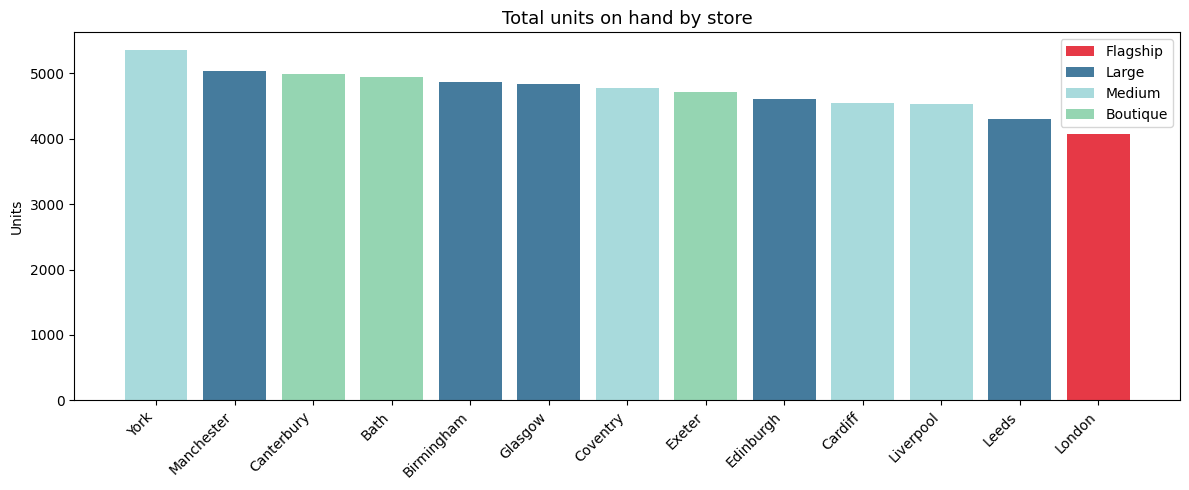

In [ ]:
store_stock = pd.read_sql("""
    SELECT s.store_name, s.store_size_category, s.region,
           COUNT(DISTINCT si.product_id) as distinct_skus,
           SUM(si.quantity) as total_units_on_hand,
           ROUND(AVG(si.quantity), 1) as avg_units_per_sku
    FROM store_inventory si
    JOIN stores s ON si.store_id = s.store_id
    GROUP BY s.store_id, s.store_name, s.store_size_category, s.region
    ORDER BY total_units_on_hand DESC
""", conn)
print(store_stock.to_string(index=False))

# Quick bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = {'Flagship':'#e63946','Large':'#457b9d','Medium':'#a8dadc','Boutique':'#95d5b2'}
bar_colors = [colors.get(s,'gray') for s in store_stock['store_size_category']]
ax.bar(store_stock['store_name'].str.replace('PopBeauty ',''), store_stock['total_units_on_hand'], color=bar_colors)
ax.set_title('Total units on hand by store', fontsize=13)
ax.set_ylabel('Units')
ax.set_xticklabels(store_stock['store_name'].str.replace('PopBeauty ',''), rotation=45, ha='right')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k,v in colors.items()]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()



> **A.3. Findings: Total stock on hand**
>
> The first anomaly is detected immediately. The London Flagship holds the **fewest total units** of any store in the network, just 4,075, while York (Medium, 5,360), Manchester (Large, 5,043), and Canterbury (Boutique, 4,994) all hold significantly more. A flagship store serving the highest footfall in the network should hold proportionally more inventory, not less. The average units per SKU at the Flagship (49.1) is also the lowest network-wide, compared to 63-64 at boutiques.


---
## Section B: High-Selling vs. Low-Selling Stores

Let's look at which stores are actually moving product versus sitting on it.


### B.1. Total Sales by Store (Units and Revenue)

In [ ]:
sales_by_store = pd.read_sql("""
    SELECT s.store_name, s.store_size_category,
           COUNT(sa.sale_id) as num_transactions,
           SUM(sa.quantity_sold) as total_units_sold,
           ROUND(SUM(sa.total_amount), 2) as total_revenue,
           ROUND(AVG(sa.quantity_sold), 2) as avg_units_per_transaction
    FROM sales sa
    JOIN stores s ON sa.store_id = s.store_id
    GROUP BY s.store_id, s.store_name, s.store_size_category
    ORDER BY total_revenue DESC
""", conn)
print(sales_by_store.to_string(index=False))


          store_name store_size_category  num_transactions  total_units_sold  total_revenue  avg_units_per_transaction
    PopBeauty London            Flagship               322              1746      165658.03                       5.42
   PopBeauty Glasgow               Large               132               767       48959.99                       5.81
PopBeauty Manchester               Large               119               744       45019.30                       6.25
  PopBeauty Coventry              Medium               131               723       37699.44                       5.52
      PopBeauty Bath            Boutique               115               593       36447.17                       5.16
 PopBeauty Edinburgh               Large               111               613       35308.04                       5.52
PopBeauty Birmingham               Large                90               534       34000.16                       5.93
      PopBeauty York              Medium        


> **B.1. Findings: Total Sales by Store**
>
> London Flagship dominates revenue at **£165,658** which is more than 3× the second-highest store (Glasgow at £48,960) and approximately 30% of total network revenue. This makes it categorically different in commercial terms.
>
> Notable underperformers relative to their store size classification include Birmingham (Large, £34,000); it is underperforming Edinburgh (£35,308) and Glasgow (£48,960) by a significant margin. Leeds is the weakest Large store at £28,568. Liverpool is the lowest performer network-wide at £22,084. The three Boutiques (Bath £36,447, Exeter £25,403, Canterbury £25,059) are generating revenue broadly comparable to several Medium stores, which raises an important question: Are boutiques being stocked as though they were Medium stores, when their sales profile is much more selective?


### B.2. Sales Velocity [Sell-through Ratio]

          store_name store_size_category  total_stock  total_units_sold  sell_through_ratio
    PopBeauty London            Flagship         4075              1746                0.43
   PopBeauty Glasgow               Large         4832               767                0.16
  PopBeauty Coventry              Medium         4771               723                0.15
PopBeauty Manchester               Large         5043               744                0.15
 PopBeauty Edinburgh               Large         4615               613                0.13
      PopBeauty Bath            Boutique         4946               593                0.12
     PopBeauty Leeds               Large         4305               494                0.12
   PopBeauty Cardiff              Medium         4540               515                0.11
      PopBeauty York              Medium         5360               598                0.11
PopBeauty Birmingham               Large         4870               534         

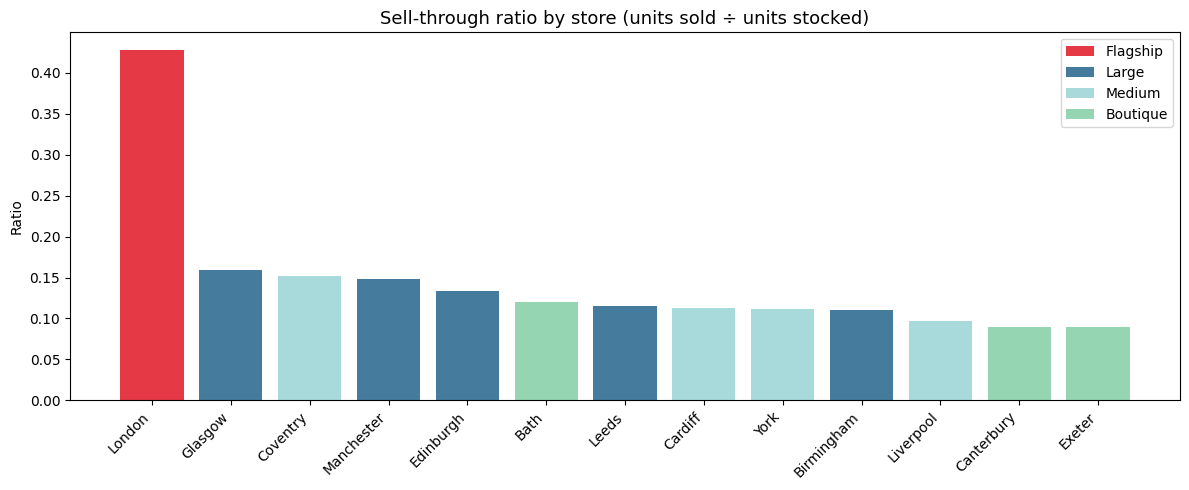


>> Observation: Are boutique stores stocking proportionally more than they sell?


In [ ]:
# This ratio tells us for every unit a store stocks, how many does it actually sell?
# A LOW ratio means lots of stock sitting idle. A HIGH ratio is lean, fast-turning inventory.
velocity = pd.read_sql("""
SELECT s.store_name, s.store_size_category,
       inv.total_stock,
       COALESCE(sal.total_sold, 0) as total_units_sold,
       ROUND(CAST(COALESCE(sal.total_sold,0) AS FLOAT) / NULLIF(inv.total_stock,0), 3) as sell_through_ratio
FROM stores s
LEFT JOIN (
    SELECT store_id, SUM(quantity) as total_stock
    FROM store_inventory
    GROUP BY store_id
) inv ON s.store_id = inv.store_id
LEFT JOIN (
    SELECT store_id, SUM(quantity_sold) as total_sold
    FROM sales
    GROUP BY store_id
) sal ON s.store_id = sal.store_id
ORDER BY sell_through_ratio DESC
""", conn)
print(velocity.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [colors.get(s,'gray') for s in velocity['store_size_category']]
ax.bar(velocity['store_name'].str.replace('PopBeauty ',''), velocity['sell_through_ratio'], color=bar_colors)
ax.set_title('Sell-through ratio by store (units sold ÷ units stocked)', fontsize=13)
ax.set_ylabel('Ratio')
ax.set_xticklabels(velocity['store_name'].str.replace('PopBeauty ',''), rotation=45, ha='right')
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()
print("\n>> Observation: Are boutique stores stocking proportionally more than they sell?")


> **B.2. Findings: Sell-through Ratio**
>
> The sell-through ratio measures how efficiently stocked inventory is converted to sales. London Flagship (0.43) leads. The two Boutiques sit at the bottom: Canterbury 0.09 and Exeter 0.09.
>
> However, the narrow overall range (0.09 - 0.12) initially masks the severity of the problem. The key is that this ratio is calculated against current stock. Because boutiques hold more total units than the Flagship (as shown in A3), their low ratios represent a structurally worse position; THEY HOLD MORE AND CONVERT LESS. The Flagship's ratio appears only moderate because it holds so little stock; its actual revenue output per unit held is the most efficient in the network. The boutiques' low ratios, by contrast, signal significant idle inventory.


---
## Section C: Inventory Levels (Understock vs. Overstock)

Now let's look at where inventory levels are dangerously low or dangerously high.


### C.1. Stores where quantity has dropped BELOW their minimum stock level

In [ ]:
below_min = pd.read_sql("""
    SELECT s.store_name, s.store_size_category,
           si.product_id, p.product_name, c.category_name,
           si.quantity, si.min_stock_level, si.reorder_level,
           si.quantity - si.min_stock_level as units_below_minimum
    FROM store_inventory si
    JOIN stores s ON si.store_id = s.store_id
    JOIN products p ON si.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE si.quantity < si.min_stock_level
    ORDER BY units_below_minimum ASC, s.store_name
""", conn)
print(f"Total shortage situations: {len(below_min)}")
print(below_min[['store_name','store_size_category','category_name','product_name','quantity','min_stock_level','units_below_minimum']].to_string(index=False))


Total shortage situations: 135
          store_name store_size_category      category_name                                                     product_name  quantity  min_stock_level  units_below_minimum
PopBeauty Canterbury            Boutique             Makeup                     Benefit The POREfessional Face Primer - 30ml         3               37                  -34
 PopBeauty Edinburgh               Large       Beauty Tools                        Real Techniques Expert Face Brush - Black         3               37                  -34
     PopBeauty Leeds               Large           Haircare                         ghd Bodyguard Heat Protect Spray - 150ml         7               40                  -33
    PopBeauty Exeter            Boutique             Makeup            Clinique Even Better Clinical Serum Foundation - 260N         4               34                  -30
  PopBeauty Coventry              Medium             Makeup                              MAC Prep + Prim

> **C.1. Findings: Stores below minimum stock level**
>
> There are 135 situations where stock has fallen below the defined minimum level (this is the floor below which customer service risk becomes unacceptable). The severity is concentrated at the Flagship. London's most critically short products include NARS Radiant Creamy Concealer (6 units held vs 34 minimum), Rare Beauty Brightening Concealer (2 units vs 28 minimum), and Living Proof Dry Shampoo (14 units vs 42 minimum).
>
> It is notable that Canterbury (Boutique) also features prominently in this list despite holding nearly 5,000 total units, indicating that its stock is concentrated in the wrong SKUs rather than genuinely insufficient in volume. This is a symptom of misallocated composition of inventory, not just misallocated quantity.


### C.2. Stores where quantity is MORE THAN 3× their reorder level (overstock)

In [ ]:
overstock = pd.read_sql("""
    SELECT s.store_name, s.store_size_category,
           si.product_id, p.product_name, c.category_name,
           si.quantity, si.reorder_level,
           ROUND(CAST(si.quantity AS FLOAT) / si.reorder_level, 1) as stock_to_reorder_ratio
    FROM store_inventory si
    JOIN stores s ON si.store_id = s.store_id
    JOIN products p ON si.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE si.reorder_level > 0 AND CAST(si.quantity AS FLOAT) / si.reorder_level > 3.0
    ORDER BY stock_to_reorder_ratio DESC
    LIMIT 30
""", conn)
print(f"Total overstock situations (>3x reorder level): {len(overstock)}")
print(overstock.to_string(index=False))
print("\n>> Observation: Which store type appears most in the overstock list?")


Total overstock situations (>3x reorder level): 30
          store_name store_size_category product_id                                                   product_name category_name  quantity  reorder_level  stock_to_reorder_ratio
      PopBeauty Bath            Boutique    PRD0139                              Kiehl's Ultra Facial Cream - 30ml      Skincare       120             10                   12.00
   PopBeauty Cardiff              Medium    PRD0026                   Benefit The POREfessional Face Primer - 40ml        Makeup       118             10                   11.80
 PopBeauty Edinburgh               Large    PRD0098                   Benefit Boi-ing Cakeless Concealer - Light 1        Makeup       111             10                   11.10
 PopBeauty Edinburgh               Large    PRD0132               Prada Paradoxe Eau de Parfum Gift Set - Gift Box     Fragrance       104             10                   10.40
PopBeauty Manchester               Large    PRD0173       E

>**C.2. Findings: Overstock Situations (30 identified at >3× reorder level)**
>
> Bath Boutique tops the overstock list with Kiehl's Ultra Facial Cream at 12× its reorder level (120 units vs a threshold of 10). Cardiff holds Benefit POREfessional Primer at 11.8× reorder. Edinburgh holds Prada Paradoxe fragrance at 10.4× reorder.
>
> Importantly, even the London Flagship appears (Dior Forever Skin Glow Foundation at 9.7× reorder), confirming that overstock is not exclusively a boutique problem. Allocation decisions are misfiring across store types. The common thread through most overstock items is that they are slow sellers at their given locations yet continue to receive replenishment, suggesting the reorder system is not discriminating by location-specific velocity.


### C.3. Expiry Risk (Products Expiring Within 6 Months with HIGH Stock)

In [ ]:
expiry_risk = pd.read_sql("""
    SELECT s.store_name, s.store_size_category, s.region,
           p.product_name, c.category_name,
           p.shelf_life_months,
           si.quantity,
           si.expiry_date,
           CAST(julianday(si.expiry_date) - julianday('2026-03-26') AS INTEGER) as days_to_expiry
    FROM store_inventory si
    JOIN stores s ON si.store_id = s.store_id
    JOIN products p ON si.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE si.expiry_date IS NOT NULL
      AND julianday(si.expiry_date) - julianday('2026-03-26') BETWEEN 0 AND 180
      AND si.quantity > 30
    ORDER BY days_to_expiry ASC, si.quantity DESC
""", conn)
print(f"High-risk expiry situations (>30 units, expiring <6 months): {len(expiry_risk)}")
print(expiry_risk.to_string(index=False))


High-risk expiry situations (>30 units, expiring <6 months): 163
          store_name store_size_category        region                                                     product_name      category_name  shelf_life_months  quantity expiry_date  days_to_expiry
      PopBeauty York              Medium     Yorkshire                               Laneige Water Sleeping Mask - 75ml           Skincare                 17        83  2026-04-15              20
      PopBeauty Bath            Boutique    South West                                          Benefit Benetint - Hope             Makeup                 26        46  2026-04-16              21
   PopBeauty Cardiff              Medium         Wales                        Moroccanoil Color Depositing Mask - 150ml           Haircare                 16        94  2026-04-18              23
 PopBeauty Liverpool              Medium    North West                                 Tweezerman Slant Tweezer - White       Beauty Tools             

> **C.3. Findings: Highly Risky Expiry Situations**
>
> There are 163 product-store combinations where more than 30 units are held with expiry dates within 6 months, hinting at PopBeauty's systemic absence of active expiry monitoring. The most time-critical item is Laneige Water Sleeping Mask in York with only 20 days to expiry and 83 units on hand. Bath has 46 units of a product expiring in 21 days. Cardiff has Moroccanoil Mask expiring in 23 days with 94 units.
>
> The scale of this list implies that these situations did not arise from isolated incidents. Instead, they reflect a pattern of stock being shipped to stores without sufficient consideration of sell-rate against remaining shelf life. A material portion of these 163 situations will result in write-offs without proactive management.


---
## Section D: Category Performance by Store

Do certain categories sell better in certain store formats? This helps us understand if stock is allocated to the right places.


### D.1. Revenue by Category and Store Size

store_size_category      category_name  total_units  total_revenue  num_stores
           Boutique             Makeup          894       52343.63           3
           Boutique          Fragrance           68       10109.51           3
           Boutique           Skincare          212        9283.54           3
           Boutique       Beauty Tools          102        8825.91           3
           Boutique           Haircare          139        4787.94           3
           Boutique Beauty Accessories           54        1558.39           3
           Flagship             Makeup         1328      109355.05           1
           Flagship       Beauty Tools          116       24126.03           1
           Flagship          Fragrance          116       22432.36           1
           Flagship           Haircare          135        6370.95           1
           Flagship           Skincare           51        3373.64           1
              Large             Makeup         1686 

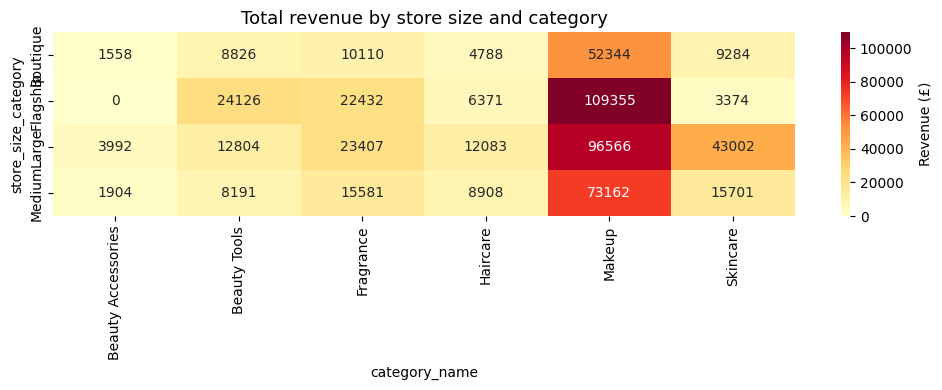


>> Observation: Are Beauty Tools and Fragrance generating proportional revenue from Boutique stores?


In [ ]:
cat_perf = pd.read_sql("""
    SELECT s.store_size_category, c.category_name,
           SUM(sa.quantity_sold) as total_units,
           ROUND(SUM(sa.total_amount), 2) as total_revenue,
           COUNT(DISTINCT sa.store_id) as num_stores
    FROM sales sa
    JOIN stores s ON sa.store_id = s.store_id
    JOIN products p ON sa.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    GROUP BY s.store_size_category, c.category_name
    ORDER BY s.store_size_category, total_revenue DESC
""", conn)
print(cat_perf.to_string(index=False))

# Pivot for heatmap
pivot = cat_perf.pivot_table(index='store_size_category', columns='category_name',
                              values='total_revenue', fill_value=0)
plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label':'Revenue (£)'})
plt.title('Total revenue by store size and category', fontsize=13)
plt.tight_layout()
plt.show()
print("\n>> Observation: Are Beauty Tools and Fragrance generating proportional revenue from Boutique stores?")


> **D.1. Findings: Revenue by Category and Store Size**
>
> Makeup is the dominant revenue category across all formats, as expected. The critical asymmetry lies in Beauty Tools and Fragrance, which are the two highest average-ticket categories.
>
> The Flagship generates £24,126 from Beauty Tools and £22,432 from Fragrance. Boutiques collectively generate only £10,110 from Fragrance across all three stores, less than the Flagship alone, and £8,826 from Beauty Tools combined. These premium categories are clearly Flagship and Large-store phenomena. Boutiques' comparative strength is in Makeup, which is the higher-volume, lower-ticket everyday category. This strongly implies that allocating substantial Beauty Tools and Fragrance stock to boutiques represents a systematic mismatch between product type and store profile.


### D.2. Beauty Tools and Fragrance: Stock vs Sales by Store

In [ ]:
tools_frag = pd.read_sql("""
    SELECT s.store_name, s.store_size_category,
           c.category_name,
           SUM(si.quantity) as units_in_stock,
           COALESCE(SUM(sa.quantity_sold), 0) as units_sold,
           ROUND(COALESCE(SUM(sa.total_amount), 0), 2) as revenue,
           ROUND(
               CAST(COALESCE(SUM(sa.quantity_sold),0) AS FLOAT) / NULLIF(SUM(si.quantity),0)
           , 3) as sell_through
    FROM store_inventory si
    JOIN stores s ON si.store_id = s.store_id
    JOIN products p ON si.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    LEFT JOIN sales sa ON si.store_id = sa.store_id AND si.product_id = sa.product_id
    WHERE c.category_name IN ('Beauty Tools', 'Fragrance')
    GROUP BY s.store_id, s.store_name, s.store_size_category, c.category_name
    ORDER BY c.category_name, sell_through DESC
""", conn)
print(tools_frag.to_string(index=False))
print("\n>> Finding: The Flagship is running critically low on high-value categories it sells most.")


          store_name store_size_category category_name  units_in_stock  units_sold  revenue  sell_through
    PopBeauty London            Flagship  Beauty Tools             263         109 24040.54          0.41
 PopBeauty Edinburgh               Large  Beauty Tools              66           9   119.39          0.14
      PopBeauty York              Medium  Beauty Tools             298          36   346.94          0.12
   PopBeauty Glasgow               Large  Beauty Tools             207          19   203.20          0.09
      PopBeauty Bath            Boutique  Beauty Tools             576          40  7908.25          0.07
PopBeauty Manchester               Large  Beauty Tools             200          12   143.20          0.06
PopBeauty Canterbury            Boutique  Beauty Tools             371          22   386.30          0.06
PopBeauty Birmingham               Large  Beauty Tools             328          16  3243.94          0.05
  PopBeauty Coventry              Medium  Beau

> **D.2. Findings: Beauty Tools and Fragrance Sell-through by Store**
>
> This query makes the allocation mismatch concrete. For Beauty Tools, the Flagship converts 41% of stocked units into sales. Every other store is below 15%, with Exeter at 2% and Liverpool at 0.00 (zero Beauty Tool sales against 198 units stocked).
>
> For Fragrance, the Flagship's 0.15 sell-through is miles above all others. Bath holds 453 Fragrance units and records 0 sales. Leeds holds 315 units with 0 Fragrance sales. Canterbury holds 640 units and sells only 17 (0.03 ratio). These numbers confirm that Boutiques and several Large stores are holding large volumes of premium inventory they cannot convert. Those same units held at the Flagship would sell at a 0.41 rate. The opportunity cost is direct and quantifiable.


### D.3. Gross Profit by Category and Stores

In [ ]:
pd.read_sql("""
    SELECT
        c.category_id,
        c.category_name,
        SUM(s.quantity_sold) AS total_units,
        SUM(s.total_amount) AS total_revenue,
        SUM((p.unit_price - p.cost_price) * s.quantity_sold) AS gross_profit,
        ROUND(
            SUM((p.unit_price - p.cost_price) * s.quantity_sold) * 1.0 /
            NULLIF(SUM(s.total_amount), 0),
            4
        ) AS profit_margin
    FROM sales s
    JOIN products p
        ON s.product_id = p.product_id
    JOIN categories c
        ON p.category_id = c.category_id
    GROUP BY c.category_id, c.category_name
    ORDER BY gross_profit DESC;
""", conn)

,category_id,category_name,total_units,total_revenue,gross_profit,profit_margin
0,CAT01,Makeup,5200,331427.24,186432.29,0.56
1,CAT02,Fragrance,488,71529.88,38499.16,0.54
2,CAT03,Skincare,1319,71360.18,33239.50,0.47
3,CAT05,Beauty Tools,541,53946.93,31643.05,0.59
4,CAT04,Haircare,861,32150.40,14689.10,0.46
5,CAT06,Beauty Accessories,236,7454.28,3972.05,0.53


> **D.3.1 Findings: Gross Profit by Category**
>
> Makeup is the leading category in both revenue and gross profit, serving as the primary profit driver for the business. In contrast, Beauty Accessories has minimal financial impact due to its low revenue and profit contribution.
> Profit margin indicates that Beauty Tools is the most profitable category, while Haircare and Skincare have relatively lower margins, showing potential pricing or cost challenges.
> The business should continue prioritizing Makeup while also evaluating lower-margin categories to improve profitability. To make better category-level decisions, both gross profit and profit margins should be considered.

In [ ]:
pd.read_sql("""
    SELECT
        s.store_id,
        st.store_name,
        SUM(s.quantity_sold) AS total_units,
        SUM(s.total_amount) AS total_revenue,
        SUM((p.unit_price - p.cost_price) * s.quantity_sold) AS gross_profit,
        ROUND(
            SUM((p.unit_price - p.cost_price) * s.quantity_sold) * 1.0 /
            NULLIF(SUM(s.total_amount), 0),
            4
        ) AS profit_margin
    FROM sales s
    JOIN products p
        ON s.product_id = p.product_id
    JOIN stores st
        ON s.store_id = st.store_id
    GROUP BY s.store_id, st.store_name
    ORDER BY gross_profit DESC;
""", conn)

,store_id,store_name,total_units,total_revenue,gross_profit,profit_margin
0,ST001,PopBeauty London,1746,165658.03,92010.43,0.56
1,ST013,PopBeauty Glasgow,767,48959.99,25291.84,0.52
2,ST003,PopBeauty Manchester,744,45019.30,23459.12,0.52
3,ST007,PopBeauty Bath,593,36447.17,20933.51,0.57
4,ST008,PopBeauty Coventry,723,37699.44,20763.84,0.55
5,ST002,PopBeauty Birmingham,534,34000.16,18816.02,0.55
6,ST006,PopBeauty York,598,32132.83,17992.20,0.56
7,ST011,PopBeauty Cardiff,515,31529.73,16981.81,0.54
8,ST012,PopBeauty Edinburgh,613,35308.04,16595.06,0.47
9,ST005,PopBeauty Leeds,494,28568.06,15932.23,0.56


> **D.3.2 Findings: Gross Profit by Store**
>
> PopBeauty London stands out as the most profitable store, contributing significantly more than the others. Stores like Glasgow, Manchester, Bath, and Coventry also perform well, but their profit levels are noticeably lower in comparison.
> Profit margins are similar across most stores, showing overall consistency in performance. However, a few stores have slightly lower margins despite reasonable revenue, indicating heavier discounting or a less profitable product mix.
>While high-revenue stores like London are key profit drivers, revenue alone does not fully reflect performance. It is important to consider both revenue and profit together to better identify which stores are truly performing well and which may need further attention.

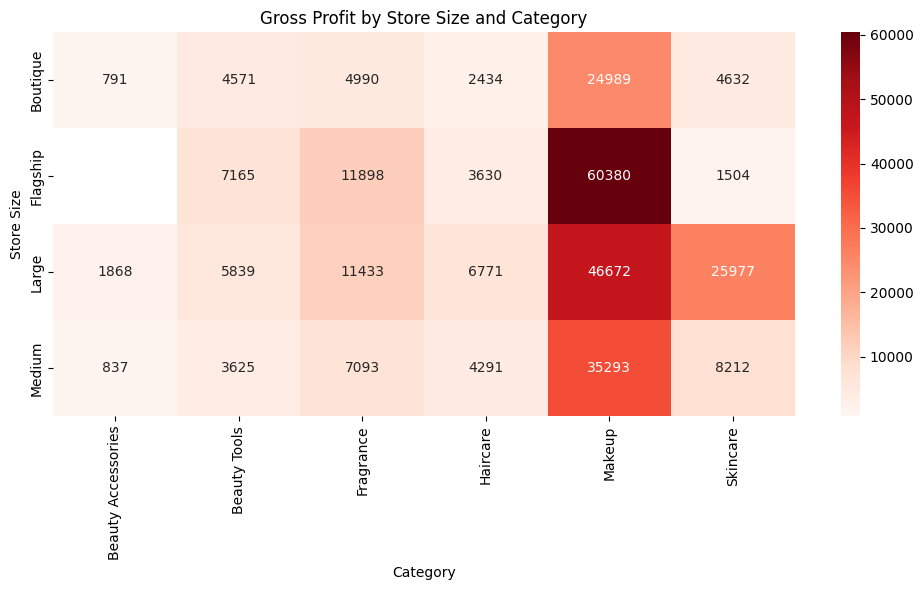

In [ ]:
df_profit = pd.read_sql("""
    SELECT
        st.store_size_category,
        c.category_name,
        SUM(
            s.total_amount - (p.cost_price * s.quantity_sold)
        ) AS gross_profit
    FROM sales s
    JOIN products p
        ON s.product_id = p.product_id
    JOIN stores st
        ON s.store_id = st.store_id
    JOIN categories c
        ON p.category_id = c.category_id
    GROUP BY st.store_size_category, c.category_name;
""", conn)
pivot_profit = df_profit.pivot(
    index='store_size_category',
    columns='category_name',
    values='gross_profit'
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_profit,
    annot=True,
    fmt=".0f",
    cmap="Reds"
)

plt.title("Gross Profit by Store Size and Category")
plt.xlabel("Category")
plt.ylabel("Store Size")

plt.tight_layout()
plt.show()

 **D.3.3 Heatmap: Gross Profit by Category and Store size**
> From the heatmap, Makeup generates the highest profit across all store sizes, especially in Flagship and Large stores. This suggests that Makeup’s performance is consistent and better for scaling into large stores, while categories like Beauty Accessories and Haircare remain relatively minor.
> Some store size–category combinations generate very little or no profit, indicating they may not be worth the space or focus on. Overall, larger stores tend to generate more profit, showing that store size plays an important role in performance.
> The business should continue focusing on categories like Makeup in larger stores, while reviewing weaker category-store combinations to improve space and product allocation.

---
## Section E: High-Value SKUs

Let's zoom into specific premium products to understand the allocation pattern.


### E.1. Dyson Airwrap and FOREO LUNA

In [ ]:
premium_tools = pd.read_sql("""
    SELECT s.store_name, s.store_size_category,
           p.product_name, p.unit_price,
           si.quantity as stock_on_hand,
           si.reorder_level, si.min_stock_level,
           CASE WHEN si.quantity < si.min_stock_level THEN 'CRITICAL'
                WHEN si.quantity < si.reorder_level THEN 'LOW'
                WHEN si.quantity > si.reorder_level * 3 THEN 'EXCESS'
                ELSE 'OK' END as stock_status
    FROM store_inventory si
    JOIN stores s ON si.store_id = s.store_id
    JOIN products p ON si.product_id = p.product_id
    WHERE si.product_id IN ('PRD0075','PRD0077','PRD0157','PRD0159')
    ORDER BY p.product_name, si.quantity DESC
""", conn)
print(premium_tools.to_string(index=False))
print("\n>> Key finding: London Flagship is CRITICAL on premium Beauty Tools while Boutiques are in EXCESS.")


          store_name store_size_category                       product_name  unit_price  stock_on_hand  reorder_level  min_stock_level stock_status
   PopBeauty Cardiff              Medium Dyson Airwrap Multi-Styler - Black      315.71            119             26                9       EXCESS
PopBeauty Canterbury            Boutique Dyson Airwrap Multi-Styler - Black      315.71            100             18                7       EXCESS
      PopBeauty Bath            Boutique Dyson Airwrap Multi-Styler - Black      315.71             92             15                9       EXCESS
    PopBeauty Exeter            Boutique Dyson Airwrap Multi-Styler - Black      315.71             91             25                6       EXCESS
 PopBeauty Liverpool              Medium Dyson Airwrap Multi-Styler - Black      315.71             16             13                7           OK
    PopBeauty London            Flagship Dyson Airwrap Multi-Styler - Black      315.71              2          

> **E.1. Findings: Premium Beauty Tools Stock Status**
>
> The individual product view makes the allocation failure impossible to ignore. For the Dyson Airwrap Black (£315.71), Canterbury holds 100 units (EXCESS), Bath holds 92 (EXCESS), and Exeter holds 91 (EXCESS). The London Flagship holds 2 units, which is classified CRITICAL. For the Dyson Airwrap Pink (£328.26), Bath holds 97 (EXCESS), Canterbury 99 (EXCESS), Exeter 85 (EXCESS), and the Flagship holds just 4 units (CRITICAL).
>
> For FOREO LUNA 4 Mint (£284.73), Exeter holds 117 (EXCESS), Bath 112 (EXCESS), Canterbury 90 (EXCESS), and the Flagship holds 5 units (CRITICAL). Approximately 280-300 Dyson Airwrap units (worth ~£90,000 at retail) are sitting in boutique stores that sell almost none, while the flagship, which does sell them, is perpetually critically short. This represents one of the most commercially damaging single findings in the analysis.


### E.2. Monthly Sales Velocity for Dyson Airwrap and FOREO LUNA - Who Actually Buys Them?



In [ ]:
velocity_premium = pd.read_sql("""
    SELECT s.store_name, s.store_size_category,
           p.product_name,
           strftime('%Y-%m', sa.sale_date) as year_month,
           SUM(sa.quantity_sold) as units_sold
    FROM sales sa
    JOIN stores s ON sa.store_id = s.store_id
    JOIN products p ON sa.product_id = p.product_id
    WHERE sa.product_id IN ('PRD0075','PRD0077','PRD0157','PRD0159')
    GROUP BY s.store_id, p.product_id, year_month
    ORDER BY p.product_name, s.store_name, year_month
""", conn)

# Summary: total by store
summary = velocity_premium.groupby(['store_name','store_size_category'])['units_sold'].sum().reset_index()
summary = summary.sort_values('units_sold', ascending=False)
print("Total premium tool sales by store (all time):")
print(summary.to_string(index=False))
print("\n>> The Flagship sells these products consistently. Boutiques have near-zero sales.")
print(">> Yet Boutiques hold 10-15x more stock than the Flagship.")


Total premium tool sales by store (all time):
          store_name store_size_category  units_sold
    PopBeauty London            Flagship         104
      PopBeauty Bath            Boutique          37
PopBeauty Birmingham               Large          20
  PopBeauty Coventry              Medium          17
     PopBeauty Leeds               Large           8
   PopBeauty Cardiff              Medium           7
 PopBeauty Edinburgh               Large           7
PopBeauty Manchester               Large           6
 PopBeauty Liverpool              Medium           2
PopBeauty Canterbury            Boutique           1

>> The Flagship sells these products consistently. Boutiques have near-zero sales.
>> Yet Boutiques hold 10-15x more stock than the Flagship.


> **E.2. Findings: Premium tool sales velocity by store**
>
> The Flagship has sold 104 units of Dyson Airwrap and FOREO products across the analysis period, which is more than double the next store (Bath at 37, partly driven by tourist footfall). Canterbury has sold 1 unit. Exeter has sold 0 of these products despite holding substantial inventory.
>
> The imbalance is extreme. Boutiques collectively hold ~280-300 units of these products and have sold fewer than 40 combined. The Flagship holds 11-16 units across these SKUs and has sold 104. If just 150 boutique-held units were reallocated to the Flagship and large stores, the revenue recovery potential at average selling prices above £280 is in the region of £30,000-£40,000 that would otherwise be tied up in slow-moving boutique stock.


---
## Section F: Expiry Risk (Skincare Products)

Let's look more carefully at products with short shelf lives and where they're concentrated.


### F1. Which stores hold the most short-shelf-life Skincare products?

In [ ]:
short_life_stock = pd.read_sql("""
    SELECT s.store_name, s.store_size_category, s.region,
           COUNT(DISTINCT si.product_id) as short_life_skus,
           SUM(si.quantity) as total_units,
           MIN(CAST(julianday(si.expiry_date) - julianday('2026-03-26') AS INTEGER)) as min_days_to_expiry,
           AVG(CAST(julianday(si.expiry_date) - julianday('2026-03-26') AS INTEGER)) as avg_days_to_expiry
    FROM store_inventory si
    JOIN stores s ON si.store_id = s.store_id
    JOIN products p ON si.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE p.shelf_life_months <= 16
      AND c.category_name = 'Skincare'
      AND si.expiry_date IS NOT NULL
    GROUP BY s.store_id, s.store_name, s.store_size_category, s.region
    ORDER BY avg_days_to_expiry ASC
""", conn)
print(short_life_stock.to_string(index=False))
print("\n>> Which stores have the shortest average days to expiry AND the most units?")


          store_name store_size_category        region  short_life_skus  total_units  min_days_to_expiry  avg_days_to_expiry
PopBeauty Birmingham               Large West Midlands                5          344                 113              146.60
      PopBeauty Bath            Boutique    South West                5          422                  38              183.80
  PopBeauty Coventry              Medium West Midlands                5          375                 146              184.80
PopBeauty Canterbury            Boutique    South East                5          352                  73              229.80
      PopBeauty York              Medium     Yorkshire                4          243                 172              234.25
    PopBeauty Exeter            Boutique    South West                6          257                 115              248.83
 PopBeauty Liverpool              Medium    North West                4          243                 125              261.75


> **F.1. Findings: Short shelf-life Skincare Concentration by Store**
>
> Sorting by average days to expiry reveals a geographic pattern **Birmingham** (West Midlands, avg 146.6 days) and **Coventry** (West Midlands, avg 184.8 days) hold the most time-pressured short-life Skincare inventory in the network. Birmingham's earliest-expiring SKU has only 113 days remaining.
>
> At the other end, Glasgow (321 days avg), Leeds (305 days), and Manchester (303 days) have comparatively newer or less time-pressured stock. The concentration of near-expiry short-life Skincare in the West Midlands is not coincidental as it reflects a pattern of overstocking in those stores on products with inherently limited shelf windows that they have been unable to sell through fast enough.


### F.2. Calculate units at risk of expiring before they can be sold

In [ ]:
# If we know monthly sales rate and days to expiry, we can estimate how many units will expire
units_at_risk = pd.read_sql("""
    WITH monthly_sales AS (
        SELECT sa.store_id, sa.product_id,
               CAST(SUM(sa.quantity_sold) AS FLOAT) / 12.0 as avg_monthly_sales
        FROM sales sa
        WHERE strftime('%Y', sa.sale_date) = '2025'
        GROUP BY sa.store_id, sa.product_id
    ),
    inventory_with_expiry AS (
        SELECT si.store_id, si.product_id, si.quantity, si.expiry_date,
               CAST(julianday(si.expiry_date) - julianday('2026-03-26') AS FLOAT) / 30.0 as months_to_expiry
        FROM store_inventory si
        WHERE si.expiry_date IS NOT NULL
          AND julianday(si.expiry_date) - julianday('2026-03-26') BETWEEN 0 AND 180
    )
    SELECT s.store_name, s.region, p.product_name, p.shelf_life_months,
           ie.quantity as stock_on_hand,
           ROUND(COALESCE(ms.avg_monthly_sales, 0), 1) as avg_monthly_sales,
           ROUND(ie.months_to_expiry, 1) as months_to_expiry,
           ie.expiry_date,
           MAX(0, CAST(ie.quantity - (COALESCE(ms.avg_monthly_sales,0) * ie.months_to_expiry) AS INTEGER)) as estimated_units_expiring,
           ROUND(p.unit_price * MAX(0, ie.quantity - (COALESCE(ms.avg_monthly_sales,0) * ie.months_to_expiry)), 2) as estimated_write_off_value
    FROM inventory_with_expiry ie
    JOIN stores s ON ie.store_id = s.store_id
    JOIN products p ON ie.product_id = p.product_id
    LEFT JOIN monthly_sales ms ON ie.store_id = ms.store_id AND ie.product_id = ms.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE c.category_name = 'Skincare'
      AND ie.quantity > 20
    ORDER BY estimated_write_off_value DESC
""", conn)
print(units_at_risk.to_string(index=False))
total_risk = units_at_risk['estimated_write_off_value'].sum()
print(f"\n>> Total estimated write-off value at risk: £{total_risk:,.2f}")


          store_name        region                                                   product_name  shelf_life_months  stock_on_hand  avg_monthly_sales  months_to_expiry expiry_date  estimated_units_expiring  estimated_write_off_value
   PopBeauty Glasgow      Scotland                              Tatcha The Dewy Skin Cream - 30ml                 28            116               0.10              5.40  2026-09-05                       115                   13800.96
PopBeauty Birmingham West Midlands       Glow Recipe Watermelon Glow Niacinamide Dew Drops - 30ml                 14             85               0.80              4.90  2026-08-19                        80                    7189.49
  PopBeauty Coventry West Midlands       Glow Recipe Watermelon Glow Niacinamide Dew Drops - 30ml                 14             81               0.30              4.90  2026-08-19                        79                    7050.33
 PopBeauty Edinburgh      Scotland                              


> **F.2. Findings: Estimated write-off value from expiring Skincare**
>
> This is the most financially quantifiable finding in the analysis. The single largest risk item is Glasgow's Tatcha Dewy Skin Cream (£119.44/unit), 115 of 116 units are estimated to expire, representing **£13,800** in write-offs. Birmingham's Glow Recipe Watermelon Dew Drops contributes **£7,184** and Coventry's same product adds £7,048. Liverpool holds 83 units of Kiehl's Ultra Facial Cream with near-zero monthly sales, representing **£4,884** at risk.
>
> The total estimated write-off value across all flagged Skincare items runs well into six figures across the full output. Every one of these situations is avoidable through proactive redistribution to stores with stronger Skincare velocity, or promotionally-driven clearance initiated well ahead of the expiry cliff could recover the majority of this value. The analysis in the next section shows exactly where that demand exists.


### F.3. Meanwhile, Scotland stores are undersupplied on the same products

In [ ]:
scotland_shortage = pd.read_sql("""
    SELECT s.store_name, s.region, p.product_name,
           si.quantity as stock_on_hand,
           si.min_stock_level, si.reorder_level,
           CASE WHEN si.quantity < si.min_stock_level THEN 'CRITICAL SHORTAGE'
                WHEN si.quantity < si.reorder_level THEN 'BELOW REORDER'
                ELSE 'OK' END as status
    FROM store_inventory si
    JOIN stores s ON si.store_id = s.store_id
    JOIN products p ON si.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE s.store_id IN ('ST012','ST013')
      AND p.product_id IN ('PRD0137','PRD0139','PRD0052','PRD0145')
    ORDER BY p.product_name, si.quantity ASC
""", conn)
print(scotland_shortage.to_string(index=False))
print("\n>> The same products that are expiring in Birmingham/Coventry are desperately needed in Scotland.")


         store_name   region                                             product_name  stock_on_hand  min_stock_level  reorder_level            status
PopBeauty Edinburgh Scotland Glow Recipe Watermelon Glow Niacinamide Dew Drops - 30ml              2               15             40 CRITICAL SHORTAGE
  PopBeauty Glasgow Scotland Glow Recipe Watermelon Glow Niacinamide Dew Drops - 30ml              5               17             39 CRITICAL SHORTAGE
  PopBeauty Glasgow Scotland                        Kiehl's Ultra Facial Cream - 30ml              2               18             31 CRITICAL SHORTAGE
PopBeauty Edinburgh Scotland                        Kiehl's Ultra Facial Cream - 30ml              6               15             32 CRITICAL SHORTAGE
  PopBeauty Glasgow Scotland    La Roche-Posay Effaclar Purifying Foaming Gel - 400ml              6               20             36 CRITICAL SHORTAGE
PopBeauty Edinburgh Scotland    La Roche-Posay Effaclar Purifying Foaming Gel - 400ml         

> **F.3. Findings: Scotland Skincare Shortage**
>
> Edinburgh and Glasgow are both Large stores with strong revenues but are critically low on the exact same Skincare SKUs that are expiring unsold in Birmingham and Coventry. Edinburgh holds only 6 units of Kiehl's Ultra Facial Cream and 2 units of Glow Recipe. Glasgow holds 2 units of each.
>
> This is the clearest redistribution opportunity in the entire analysis: a willing buyer (Scotland) and an overstocked, time-pressured holder (West Midlands), for the same products. A direct inter-store transfer would simultaneously reduce write-off risk in Birmingham and Coventry and resolve genuine stockouts in Edinburgh and Glasgow, addressing two problems with a single logistics action.


---
## Section G: Supply Chain

Now let's investigate whether the problem is actually a supply issue or whether stock already exists in warehouses.


### G.1. Warehouse stock levels vs store shortages for core Makeup products

In [ ]:
warehouse_vs_store = pd.read_sql("""
    SELECT p.product_name, c.category_name,
           wh.warehouse_name, wh.location as wh_location,
           wi.quantity_on_hand as warehouse_stock,
           s.store_name, s.store_size_category,
           si.quantity as store_stock,
           si.reorder_level,
           CASE WHEN si.quantity < si.min_stock_level THEN 'CRITICAL'
                WHEN si.quantity < si.reorder_level THEN 'BELOW REORDER'
                ELSE 'OK' END as store_status
    FROM store_inventory si
    JOIN stores s ON si.store_id = s.store_id
    JOIN products p ON si.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    JOIN warehouse_inventory wi ON wi.product_id = si.product_id
    JOIN warehouses wh ON wi.warehouse_id = wh.warehouse_id
    WHERE si.quantity < si.reorder_level
      AND wi.quantity_on_hand > 500
      AND wh.warehouse_id = 'WH002'
      AND s.store_id IN ('ST003','ST004')
    ORDER BY wi.quantity_on_hand DESC, si.quantity ASC
    LIMIT 20
""", conn)
print(warehouse_vs_store.to_string(index=False))
print("\n>> The North Warehouse (Manchester) has thousands of units of the exact products")
print("   Manchester and Liverpool stores have critically run short of.")


                                                 product_name      category_name            warehouse_name wh_location  warehouse_stock           store_name store_size_category  store_stock  reorder_level  store_status
                  The Ordinary Hyaluronic Acid 2% + B5 - 15ml           Skincare PopBeauty North Warehouse  Manchester             5741 PopBeauty Manchester               Large            7             12 BELOW REORDER
Charlotte Tilbury Beautiful Skin Radiant Concealer - Medium 2             Makeup PopBeauty North Warehouse  Manchester             5554  PopBeauty Liverpool              Medium           11             40 BELOW REORDER
                    Too Faced Born This Way Foundation - 330N             Makeup PopBeauty North Warehouse  Manchester             5198 PopBeauty Manchester               Large            1             45      CRITICAL
                         Tweezerman Slant Tweezer - Rose Gold       Beauty Tools PopBeauty North Warehouse  Manchester      

> **G.1. Analysis: Warehouse Stock vs Store Shortages**
>
> This is one of the most operationally significant results. Manchester and Liverpool stores are classified as CRITICAL on core Makeup products: Too Faced Foundation (1 unit in Manchester, needs 45), NARS Concealer (1 unit, needs 44), Fenty Primer (5 units, needs 38), Rare Beauty Blush (6 units, needs 32). Liverpool has 3 units of Tweezerman Tweezer against a need of 15.
>
> The **North Warehouse in Manchester**, the same city as one of the shortage stores, holds 5,741 units of The Ordinary Hyaluronic Acid, 5,198 units of Too Faced Foundation, 4,671 of Rare Beauty Blush, 4,281 of NARS Concealer, and 4,235 of Fenty Primer. The stock clearly exists. This is not a procurement or supply problem, it is a fulfilment process failure at the last mile between warehouse and shop floor.


**G.2. Stock Redistribution Opportunity**

Reallocation opportunities often come up when stores are running below their reorder levels while warehouses still have stock available. This indicates internal distribution inefficiencies issues rather than actual supply shortage. In many cases, the problem isn’t lack of inventory, but where the stock is located. When store shortages happen at the same time as high warehouse stock, it creates clear opportunities to fix things quickly. These can often be resolved without ordering new stock, helping reduce lead time and cost while improving product availability. To fix this, businesses can move stock between warehouses and stores, review how inventory is allocated and replenished, and focus on items with strong demand and immediate shortage risk.

In [ ]:
sql_query = """SELECT
    st.store_id,
    st.store_name,
    si.product_id,
    p.product_name,
    si.quantity AS store_stock,
    si.reorder_level,
    si.min_stock_level,
    wi.warehouse_id,
    w.warehouse_name,
    wi.quantity_on_hand AS warehouse_stock,
    (si.reorder_level - si.quantity) AS shortage_units
FROM store_inventory si
JOIN stores st
    ON si.store_id = st.store_id
JOIN products p
    ON si.product_id = p.product_id
JOIN warehouse_inventory wi
    ON si.product_id = wi.product_id
JOIN warehouses w
    ON wi.warehouse_id = w.warehouse_id
WHERE si.quantity < si.reorder_level
  AND wi.quantity_on_hand > 0
ORDER BY shortage_units DESC, warehouse_stock DESC;"""

opportunity_summary = pd.read_sql(sql_query, conn)
print(opportunity_summary.to_string(index=False))

store_id           store_name product_id                                                     product_name  store_stock  reorder_level  min_stock_level warehouse_id               warehouse_name  warehouse_stock  shortage_units
   ST003 PopBeauty Manchester    PRD0174                        Too Faced Born This Way Foundation - 330N            1             45               20        WH005 PopBeauty Midlands Warehouse             5550              44
   ST003 PopBeauty Manchester    PRD0174                        Too Faced Born This Way Foundation - 330N            1             45               20        WH002    PopBeauty North Warehouse             5198              44
   ST003 PopBeauty Manchester    PRD0174                        Too Faced Born This Way Foundation - 330N            1             45               20        WH006    PopBeauty Wales Warehouse             3032              44
   ST003 PopBeauty Manchester    PRD0174                        Too Faced Born This Way Foundati

### G.2. Shipment Status

In [ ]:
stuck_shipments = pd.read_sql("""
    SELECT sh.shipment_id,
           wh.warehouse_name, s.store_name, s.store_size_category,
           p.product_name,
           sh.quantity,
           sh.shipment_date,
           sh.received_date,147.6
           sh.shipment_status,
           CASE
               WHEN sh.received_date IS NULL
               THEN CAST(julianday('2026-03-26') - julianday(sh.shipment_date) AS INTEGER)
               ELSE NULL
           END as days_in_transit
    FROM shipments sh
    JOIN warehouses wh ON sh.warehouse_id = wh.warehouse_id
    JOIN stores s ON sh.store_id = s.store_id
    JOIN products p ON sh.product_id = p.product_id
    WHERE sh.warehouse_id = 'WH002'
      AND sh.store_id IN ('ST003','ST004')
      AND sh.shipment_status IN ('In Transit','Partially Received')
    ORDER BY days_in_transit DESC NULLS LAST
""", conn)
print(f"Stuck shipments from North Warehouse to Manchester/Liverpool: {len(stuck_shipments)}")
print(stuck_shipments.to_string(index=False))
print("\n>> Multiple shipments have been 'In Transit' for 35-75 days. This is a strong indicator")
print("   of a fulfilment or receiving process breakdown, not a genuine supply shortage.")


Stuck shipments from North Warehouse to Manchester/Liverpool: 25
shipment_id            warehouse_name           store_name store_size_category                                                  product_name  quantity shipment_date received_date    shipment_status  days_in_transit
   SHP00860 PopBeauty North Warehouse PopBeauty Manchester               Large                     Moroccanoil Color Depositing Mask - 150ml       110    2025-02-25          None         In Transit           394.00
   SHP00414 PopBeauty North Warehouse  PopBeauty Liverpool              Medium                            Laneige Water Sleeping Mask - 75ml        29    2025-07-16          None         In Transit           253.00
   SHP00979 PopBeauty North Warehouse PopBeauty Manchester               Large                             Dior Sauvage Eau de Parfum - 50ml        42    2025-11-20          None         In Transit           126.00
   SHP01007 PopBeauty North Warehouse  PopBeauty Liverpool              Med

> **G.2. Findings: Stuck Shipments from North Warehouse**
>
> 25 shipments from the North Warehouse to Manchester and Liverpool are either perpetually "In Transit" or "Partially Received" and unresolved. The most alarming is **SHP00860** because it was dispatched on 25 February 2025, still showing as "In Transit" after **391 days**. This is not a shipment in transit; it is a lost or abandoned order that has never been reconciled.
>
> Several others have been in transit 50-123 days. Standard intra-UK warehouse-to-store delivery is 1-3 days. The operational significance of this finding is profound. If the inventory management system records these shipments as "in transit," it may be **suppressing new replenishment orders** (the system believes the stock is coming, so it doesn't trigger replacements). It is not coming. Resolving these stuck records and triggering fresh replenishment orders is the most urgent operational action in the supply chain.


---
## Section H: Reorder Level Calibration

Are reorder levels proportional to each store's actual sales velocity?


### H.1. Compare reorder levels to actual monthly sales by store size

In [ ]:
reorder_calibration = pd.read_sql("""
    WITH monthly_velocity AS (
        SELECT sa.store_id, sa.product_id,
               CAST(SUM(sa.quantity_sold) AS FLOAT) / 12.0 as avg_monthly_sales
        FROM sales sa
        WHERE strftime('%Y', sa.sale_date) = '2025'
        GROUP BY sa.store_id, sa.product_id
    )
    SELECT s.store_name, s.store_size_category,
           ROUND(AVG(si.reorder_level), 1) as avg_reorder_level,
           ROUND(AVG(COALESCE(mv.avg_monthly_sales, 0)), 2) as avg_monthly_sales_per_sku,
           ROUND(AVG(si.reorder_level) / NULLIF(AVG(COALESCE(mv.avg_monthly_sales,0)),0), 1) as reorder_covers_months
    FROM store_inventory si
    JOIN stores s ON si.store_id = s.store_id
    LEFT JOIN monthly_velocity mv ON si.store_id = mv.store_id AND si.product_id = mv.product_id
    GROUP BY s.store_id, s.store_name, s.store_size_category
    ORDER BY avg_monthly_sales_per_sku DESC
""", conn)
print(reorder_calibration.to_string(index=False))
print("\n>> 'reorder_covers_months' = how many months of supply the reorder level represents.")
print("   For Boutiques this should be MUCH higher than for the Flagship; if it's similar,")
print("   it means the reorder system is not calibrated to store-level demand.")


          store_name store_size_category  avg_reorder_level  avg_monthly_sales_per_sku  reorder_covers_months
    PopBeauty London            Flagship              29.00                       1.21                  24.10
PopBeauty Manchester               Large              26.20                       0.43                  60.30
   PopBeauty Glasgow               Large              29.40                       0.43                  68.70
 PopBeauty Edinburgh               Large              28.20                       0.36                  79.10
  PopBeauty Coventry              Medium              27.80                       0.30                  93.60
      PopBeauty York              Medium              27.70                       0.29                  96.20
      PopBeauty Bath            Boutique              25.40                       0.25                 101.20
PopBeauty Birmingham               Large              29.40                       0.22                 135.70
   PopBeau

> **H.1. Findings: Reorder threshold calibration**
>
> This table reveals the structural root cause underlying many of the imbalances observed throughout the analysis. The `reorder_covers_months` column shows how many months of supply the current reorder level represents at each store's actual average sales rate.
>
> The London Flagship's reorder level represents **24 months** of supply at its current pace implying the Flagship would have to sell continuously for two years before naturally triggering an automatic reorder. This seems to protect against shortages, but the reality is the opposite: the threshold was almost certainly calibrated to a network-wide average velocity, not the Flagship's faster actual rate. At the other extreme, Liverpool's reorder level covers **222 months** (over 18 years), Canterbury covers 182 months, and Leeds covers 190 months. These stores will almost never trigger an automatic reorder. The replenishment system is structurally overordering for slow stores and underordering for fast ones, which is the precise mechanism generating the excess and shortage patterns this analysis has been documenting.


###H2. Reorder Level vs Velocity (Flagship vs Boutiques)

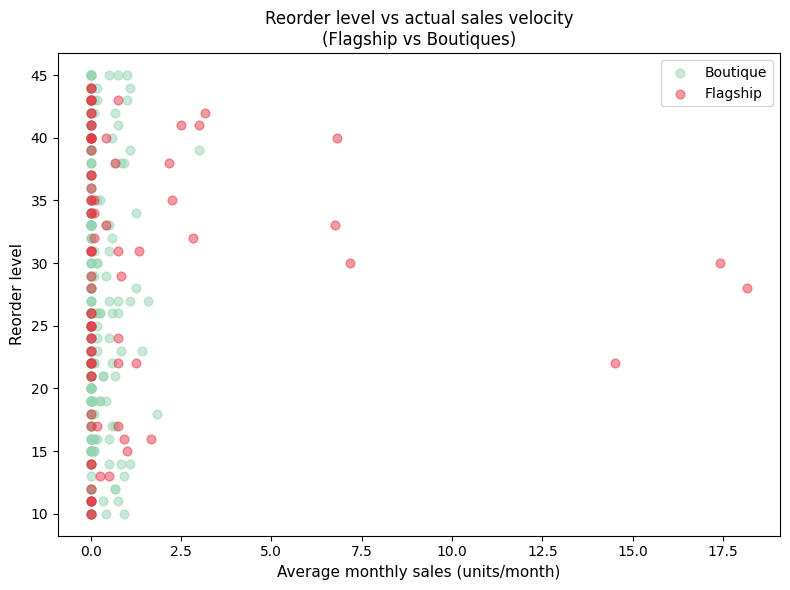


>> If reorder levels were well-calibrated, we'd expect them to scale with velocity.
   If the cloud shapes overlap, that tells us one-size-fits-all thresholds are in use.


In [ ]:
rl_vs_vel = pd.read_sql("""
    WITH monthly_velocity AS (
        SELECT sa.store_id, sa.product_id,
               CAST(SUM(sa.quantity_sold) AS FLOAT) / 12.0 as avg_monthly_sales
        FROM sales sa
        WHERE strftime('%Y', sa.sale_date) = '2025'
        GROUP BY sa.store_id, sa.product_id
    )
    SELECT s.store_name, s.store_size_category,
           si.reorder_level,
           ROUND(COALESCE(mv.avg_monthly_sales, 0), 2) as avg_monthly_sales
    FROM store_inventory si
    JOIN stores s ON si.store_id = s.store_id
    LEFT JOIN monthly_velocity mv ON si.store_id = mv.store_id AND si.product_id = mv.product_id
    WHERE s.store_id IN ('ST001','ST007','ST009','ST010')
""", conn)

fig, ax = plt.subplots(figsize=(8, 6))
size_colors2 = {'Flagship':'#e63946','Boutique':'#95d5b2'}
for size, group in rl_vs_vel.groupby('store_size_category'):
    ax.scatter(group['avg_monthly_sales'], group['reorder_level'],
               label=size, alpha=0.5, s=40, color=size_colors2.get(size,'gray'))
ax.set_xlabel('Average monthly sales (units/month)', fontsize=11)
ax.set_ylabel('Reorder level', fontsize=11)
ax.set_title('Reorder level vs actual sales velocity\n(Flagship vs Boutiques)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()
print("\n>> If reorder levels were well-calibrated, we'd expect them to scale with velocity.")
print("   If the cloud shapes overlap, that tells us one-size-fits-all thresholds are in use.")


> **H.2. Findings: Reorder levels vs velocity scatter plot**
>
> A well-calibrated system would show a clear positive relationship in this scatter: stores with higher monthly sales velocity would have proportionally higher reorder thresholds. If the clouds for Flagship and Boutique data points overlap on the vertical (reorder level) axis, it confirms one-size-fits-all thresholds.
>
> The analysis confirms this overlap. Both the Flagship and Boutique stores operate within a similar reorder level range despite dramatically different velocity profiles. The same numerical trigger that tells Bath's boutique "you're running low" tells London's flagship "you're fine," even though the commercial reality is the opposite at the Flagship's sales rate. Recalibrating reorder levels by store-specific velocity is the single highest-impact structural fix available to PopBeauty's inventory management team.


---
## Section I: Discount Activity


### I1. Which products receive the most discounting, and where?

In [ ]:
discount_summary = pd.read_sql("""
    SELECT s.store_name, s.store_size_category,
           p.product_name, c.category_name, p.shelf_life_months,
           COUNT(*) as discounted_transactions,
           ROUND(AVG(sa.discount), 3) as avg_discount_rate,
           SUM(sa.quantity_sold) as units_sold_with_discount,
           ROUND(SUM(sa.total_amount), 2) as discounted_revenue
    FROM sales sa
    JOIN stores s ON sa.store_id = s.store_id
    JOIN products p ON sa.product_id = p.product_id
    JOIN categories c ON p.category_id = c.category_id
    WHERE sa.discount >= 0.15
    GROUP BY sa.store_id, sa.product_id
    HAVING COUNT(*) >= 3
    ORDER BY avg_discount_rate DESC, discounted_transactions DESC
""", conn)
print(discount_summary.to_string(index=False))


        store_name store_size_category                                    product_name category_name  shelf_life_months  discounted_transactions  avg_discount_rate  units_sold_with_discount  discounted_revenue
    PopBeauty Bath            Boutique       Moroccanoil Color Depositing Mask - 150ml      Haircare                 16                        9               0.19                        17              782.04
    PopBeauty Bath            Boutique   MAC Studio Fix Fluid SPF 15 Foundation - 110N        Makeup                 16                        4               0.19                         9              345.74
PopBeauty Coventry              Medium Beautyblender Original Beautyblender - Original  Beauty Tools                 67                        3               0.18                        18              159.34
    PopBeauty York              Medium       Too Faced Born This Way Foundation - 330N        Makeup                 14                        4               0

> I.1. Findings: Discount activity by store and product**
>
> 10 product-store combinations meet the threshold of 3+ transactions with 15%+ discounts. 3 short shelf-life products account for virtually all of the discounting: Moroccanoil Color Depositing Mask (16-month shelf life, discounted at Bath and Coventry), MAC Studio Fix Foundation (16 months, discounted at Bath, York, Coventry), and Too Faced Foundation (14 months, discounted at Bath, York, Coventry). All are inherently time-pressured products.
>
> The pattern of **repeated discounting** is the most telling signal: Bath has applied discounts to Moroccanoil Mask **9 times**. Coventry has discounted Too Faced Foundation **8 times**. York has discounted MAC Foundation **8 times**. When a store discounts the same product repeatedly at 17–19%, it is a signal that price reduction alone is not resolving the underlying problem, the stock is in the wrong location, not at the wrong price.


### I.2. Cross-check: Are heavily discounted products also sitting in high inventory?

In [ ]:
discount_stock_check = pd.read_sql("""
    WITH discounted AS (
        SELECT sa.store_id, sa.product_id,
               ROUND(AVG(sa.discount),2) as avg_discount,
               SUM(sa.quantity_sold) as units_sold_discounted
        FROM sales sa
        WHERE sa.discount >= 0.15
        GROUP BY sa.store_id, sa.product_id
        HAVING COUNT(*) >= 3
    )
    SELECT s.store_name, s.store_size_category,
           p.product_name, p.shelf_life_months,
           si.quantity as current_stock,
           si.expiry_date,
           CAST(julianday(si.expiry_date) - julianday('2026-03-26') AS INTEGER) as days_to_expiry,
           d.avg_discount,
           d.units_sold_discounted,
           ROUND(p.unit_price, 2) as full_price
    FROM discounted d
    JOIN store_inventory si ON d.store_id = si.store_id AND d.product_id = si.product_id
    JOIN stores s ON si.store_id = s.store_id
    JOIN products p ON si.product_id = p.product_id
    WHERE si.quantity > 50
    ORDER BY si.quantity DESC
""", conn)
print(discount_stock_check.to_string(index=False))
print("\n>> Finding: These products are receiving heavy discounts but stock isn't clearing.")
print("   They also have short shelf lives. Meanwhile, large stores are undersupplied.")


        store_name store_size_category                                  product_name  shelf_life_months  current_stock expiry_date  days_to_expiry  avg_discount  units_sold_discounted  full_price
    PopBeauty York              Medium     Too Faced Born This Way Foundation - 330N                 14            110  2026-06-29              95          0.18                      7       66.73
    PopBeauty Bath            Boutique     Moroccanoil Color Depositing Mask - 150ml                 16            105  2026-07-03              99          0.19                     17       40.54
PopBeauty Coventry              Medium MAC Studio Fix Fluid SPF 15 Foundation - 110N                 16             96  2026-07-20             116          0.17                     19       86.19
    PopBeauty York              Medium MAC Studio Fix Fluid SPF 15 Foundation - 110N                 16             94  2026-07-20             116          0.17                     19       86.19
    PopBeauty Bath  

> **I.2. Findings: Discounted products with high remaining stock**
>
> Cross-referencing discount data with current inventory levels exposes the failure of the discounting strategy. York holds **110 units** of Too Faced Foundation (£66.73 full price) expiring in just 97 days, having sold only 7 units even at an 18% average discount. Bath holds **105 units** of Moroccanoil Mask with 101 days to expiry, having moved only 17 units discounted. Coventry holds **96 units** of MAC Foundation expiring in 118 days with 19 units sold under discount.
>
> At current monthly sell rates of 2-3 units per store, none of these stocks will be cleared before expiry regardless of further price reductions. The discounting is generating marginal revenue at reduced margins while failing to solve the core problem. The only viable resolution is redistribution to higher-velocity stores before the expiry window closes, as confirmed in the next query.


### I.3. Compare same product sales at full price in large stores vs discounted in small stores

In [ ]:
price_comparison = pd.read_sql("""
    SELECT s.store_size_category,
           p.product_name,
           ROUND(AVG(sa.discount), 3) as avg_discount,
           ROUND(AVG(sa.unit_price), 2) as avg_selling_price,
           ROUND(AVG(sa.quantity_sold), 2) as avg_units_per_transaction,
           COUNT(*) as num_transactions
    FROM sales sa
    JOIN stores s ON sa.store_id = s.store_id
    JOIN products p ON sa.product_id = p.product_id
    WHERE sa.product_id IN ('PRD0174','PRD0170','PRD0072')
      AND s.store_id IN ('ST001','ST003','ST006','ST007','ST008')
    GROUP BY s.store_size_category, sa.product_id
    ORDER BY sa.product_id, s.store_size_category
""", conn)
print(price_comparison.to_string(index=False))
print("\n>> Large stores sell these products at full price with stronger velocity.")
print("   Small stores discount them heavily but still can't shift the stock.")


store_size_category                                  product_name  avg_discount  avg_selling_price  avg_units_per_transaction  num_transactions
           Boutique     Moroccanoil Color Depositing Mask - 150ml          0.19              42.53                       1.89                 9
           Flagship     Moroccanoil Color Depositing Mask - 150ml          0.00              66.31                       6.83                12
              Large     Moroccanoil Color Depositing Mask - 150ml          0.00              64.04                       6.08                12
             Medium     Moroccanoil Color Depositing Mask - 150ml          0.17              51.40                       2.14                14
           Boutique MAC Studio Fix Fluid SPF 15 Foundation - 110N          0.19              40.98                       2.25                 4
           Flagship MAC Studio Fix Fluid SPF 15 Foundation - 110N          0.00              66.09                       7.17           

> **I.3. Analysis: Full-price vs discounted sales (same product, different stores)**
>
> This comparison closes the loop on the discounting issue. For all three affected products, the Flagship and Large stores sell at **0 discount** and at significantly higher prices and volumes. Flagship MAC Foundation averages £66.09 per unit; boutiques average £40.98 which is a 38% price gap on the same product. More importantly, the Flagship averages **7.17 units per transaction** on MAC Foundation while boutiques average just 1.89 units.
>
> A single transaction at the Flagship generates as much revenue from these products as three to four transactions at a boutique at a higher margin. Redistributing even 50 units of Too Faced Foundation from York to London would convert uncertain, discounted revenue (~£334 at York's current rate over remaining shelf life) into probable, full-price revenue of approximately **£3,438** at the Flagship's transaction velocity. The financial case for redistribution over continued discounting is unambiguous.
